In [102]:
import pandas as pd
from process_and_save_recording import load_recording, convert_events_to_watch_time
from plot_signal import plot_signal

In [103]:
path = "session_1776875240569"
accel, gyro, classification, annotation, info = load_recording(path)

In [104]:
events_watch_time = convert_events_to_watch_time(annotation, info)

In [105]:
events_watch_time

[{'name': 'Bulgarian Split Squat',
  'start_watch': 1776875869797,
  'end_watch': 1776875916837},
 {'name': 'Bulgarian Split Squat',
  'start_watch': 1776876219895,
  'end_watch': 1776876269730},
 {'name': 'Romanian Deadlifts',
  'start_watch': 1776876655485,
  'end_watch': 1776876696057},
 {'name': 'Romanian Deadlifts',
  'start_watch': 1776876875935,
  'end_watch': 1776876936900},
 {'name': 'Dumbell Chest Flys',
  'start_watch': 1776877263101,
  'end_watch': 1776877306098},
 {'name': 'Dumbell Chest Flys',
  'start_watch': 1776877506774,
  'end_watch': 1776877555852},
 {'name': 'Straight Arm Lat Pulldowns',
  'start_watch': 1776877700933,
  'end_watch': 1776877745133},
 {'name': 'Straight Arm Lat Pulldowns',
  'start_watch': 1776877892422,
  'end_watch': 1776877945634},
 {'name': 'Hammer Curls',
  'start_watch': 1776878256067,
  'end_watch': 1776878294501},
 {'name': 'Hammer Curls',
  'start_watch': 1776878498301,
  'end_watch': 1776878534400},
 {'name': 'Dumbbell Lateral Raises',
  '

In [106]:
classification

,timestamp,prediction_float,prediction_binary,accel_timestamps,gyro_timestamps,window_data
0,1776875241945,0.049393,0,528122621957415;528122642036453;52812266217468...,528122621959838;528122642039146;52812266217714...,2.2170308|0.30885202|10.941502|0.40194935|0.58...
1,1776875242952,0.085727,0,528123624681488;528123645286988;52812366713025...,528123624683950;528123645289680;52812366713271...,0.45010993|2.0398598|9.385271|-0.1600467|0.200...
2,1776875243960,0.152955,0,528124629797176;528124647555907;52812466761467...,528124629799638;528124647558600;52812466761709...,0.6775591|3.040636|9.141062|0.3885103|-0.03420...
3,1776875244968,0.063340,0,528125630228134;528125650253826;52812567034148...,528125630230557;528125650256519;52812567034394...,0.81402856|2.099715|9.519346|0.5216789|-0.0635...
4,1776875245970,0.050801,0,528126652391015;528126672432361;52812669302432...,528126652393707;528126672434784;52812669302701...,1.9680338|-0.1436521|12.136209|-0.5864306|-0.4...
...,...,...,...,...,...,...
5505,1776880779505,0.008595,0,533660178840526;533660198949026;53366021902075...,533660178842718;533660198951449;53366021902294...,4.7644615|-6.241684|-3.6008794|1.6175711|-0.02...
5506,1776880780510,0.022464,0,533661181649868;533661201730330;53366122178136...,533661181652061;533661201732753;53366122178356...,12.140997|-7.252037|0.93373865|2.1099286|-0.75...
5507,1776880781517,0.021523,0,533662185443287;533662205480057;53366222549048...,533662185445480;533662205482480;53366222549267...,2.566584|-8.808268|6.045359|-0.1600467|0.38117...
5508,1776880782522,0.023462,0,533663189018976;533663209131784;53366322924255...,533663189021168;533663209134207;53366322924474...,-1.7190368|-7.85777|-5.837064|-2.375044|0.7855...


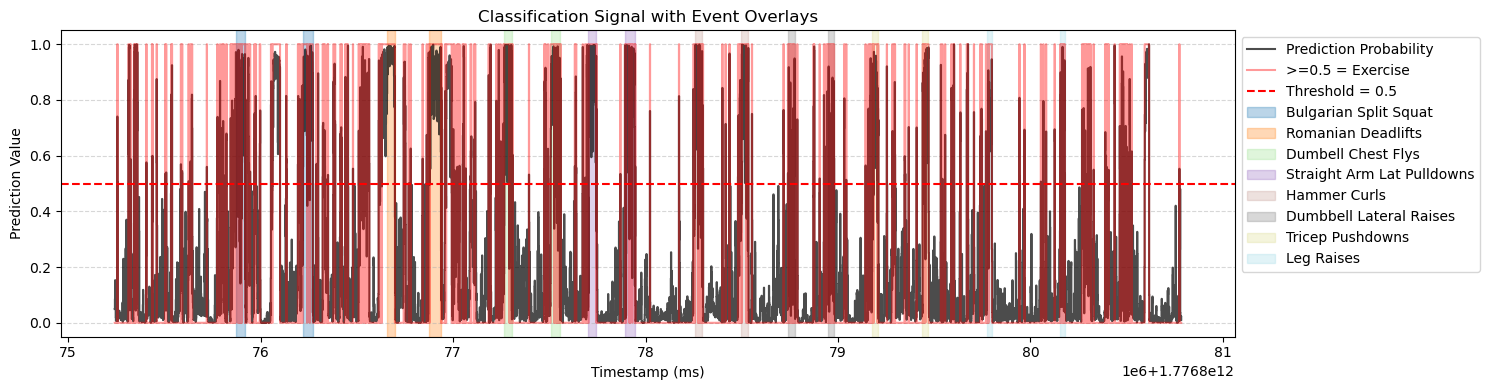

In [107]:
plot_signal(classification, events_watch_time)

In [108]:
# ignore treadmill running
ignore_list = ['Treadmill Running', 'Side Crunches',
               #'Chest Fly Machine', 'Dumbbell Overhead Press', 'Cable Rows'
               ]
filtered_events = [e for e in events_watch_time if e['name'] not in ignore_list]

# Metrics

In [109]:
def calculate_total_metrics(classification, events):
    df = classification.copy()
    
    # 1. Create Ground Truth (0 = Rest, 1 = Exercise)
    df['ground_truth'] = 0
    for event in events:
        mask = (df['timestamp'] >= event['start_watch']) & (df['timestamp'] <= event['end_watch'])
        df.loc[mask, 'ground_truth'] = 1
    
    # 2. Calculate Overall Accuracy
    # (How many times did prediction match ground truth exactly?)
    correct_total = (df['prediction_binary'] == df['ground_truth']).sum()
    total_preds = len(df)
    overall_accuracy = (correct_total / total_preds) * 100
    
    # 3. Breakdown by Class
    # Exercise Accuracy (Recall)
    exercise_mask = (df['ground_truth'] == 1)
    correct_exercise = (df.loc[exercise_mask, 'prediction_binary'] == 1).sum()
    exercise_acc = (correct_exercise / exercise_mask.sum()) * 100 if exercise_mask.sum() > 0 else 0
    
    # Rest Accuracy (Specificity)
    rest_mask = (df['ground_truth'] == 0)
    correct_rest = (df.loc[rest_mask, 'prediction_binary'] == 0).sum()
    rest_acc = (correct_rest / rest_mask.sum()) * 100 if rest_mask.sum() > 0 else 0
    
    return {
        'overall_accuracy': round(overall_accuracy, 2),
        'exercise_accuracy': round(exercise_acc, 2),
        'rest_accuracy': round(rest_acc, 2),
        'total_predictions': total_preds,
        'false_positives': int((df.loc[rest_mask, 'prediction_binary'] == 1).sum()),
        'false_negatives': int((df.loc[exercise_mask, 'prediction_binary'] == 0).sum())
    }

# Usage
total_stats = calculate_total_metrics(classification, filtered_events)
display(total_stats)

{'overall_accuracy': np.float64(87.68),
 'exercise_accuracy': np.float64(81.32),
 'rest_accuracy': np.float64(88.51),
 'total_predictions': 5510,
 'false_positives': 560,
 'false_negatives': 119}

# Detection delay

In [110]:
def calculate_latency(classification, events, buffer_ms=5000):
    results = []
    
    for event in events:
        name = event['name']
        start = event['start_watch']
        end = event['end_watch']
        
        # Filter classification rows that occur during this specific event
        # We add a small buffer (e.g., 5 seconds) just in case the detection is late
        mask = (classification['timestamp'] >= start - buffer_ms) & (classification['timestamp'] <= end)
        event_predictions = classification.loc[mask]
        
        if event_predictions.empty:
            results.append({'name': name, 'delay_ms': None, 'status': 'Not Detected'})
            continue
            
        # Find the when the model predicted '1' (Exercise)
        detected_rows = event_predictions[event_predictions['prediction_binary'] == 1]

        if not detected_rows.empty:
            # order by closest to start
            detected_rows['dist_to_start'] = (detected_rows['timestamp'] - start).abs()

            # Sort by distance and take the closest one
            closest_row = detected_rows.sort_values('dist_to_start').iloc[0]

            first_detection_ts = closest_row['timestamp']
            delay = first_detection_ts - start
            
            results.append({
                'name': name, 
                'delay_ms': round(delay, 2), 
                'delay_sec': round(delay / 1000, 2),
                'status': 'Detected'
            })
        else:
            results.append({'name': name, 'delay_ms': None, 'status': 'Missed'})

    return pd.DataFrame(results)

latency_df = calculate_latency(classification, filtered_events, buffer_ms=2000)
print(latency_df)

# Filter for successful detections
detections = latency_df[latency_df['status'] == 'Detected']['delay_sec']

# 1. Mean Error (Bias): Tells you if the model is consistently late
bias = detections.mean()

# 2. Mean Absolute Error (MAE): Tells you the typical size of the timing error
mae = detections.abs().mean()

print(f"System Bias: {bias:.2f}s (Positive means model is usually late)")
print(f"Avg Error Magnitude: {mae:.2f}s (Average distance from start)")

                          name  delay_ms  delay_sec    status
0        Bulgarian Split Squat       572       0.57  Detected
1        Bulgarian Split Squat      -144      -0.14  Detected
2           Romanian Deadlifts        96       0.10  Detected
3           Romanian Deadlifts       -48      -0.05  Detected
4           Dumbell Chest Flys     -1849      -1.85  Detected
5           Dumbell Chest Flys       -47      -0.05  Detected
6   Straight Arm Lat Pulldowns      3934       3.93  Detected
7   Straight Arm Lat Pulldowns       558       0.56  Detected
8                 Hammer Curls      1008       1.01  Detected
9                 Hammer Curls      1102       1.10  Detected
10     Dumbbell Lateral Raises     -1516      -1.52  Detected
11     Dumbbell Lateral Raises      -385      -0.38  Detected
12            Tricep Pushdowns      1720       1.72  Detected
13            Tricep Pushdowns      2129       2.13  Detected
14                  Leg Raises      6009       6.01  Detected
15      

# Segment level accuracy
Missed exercises intervals

In [111]:
def calculate_segment_accuracy(classification, events):
    results = []
    
    for event in events:
        name = event['name']
        start = event['start_watch']
        end = event['end_watch']
        
        # Slice the classification data to the event duration
        mask = (classification['timestamp'] >= start) & (classification['timestamp'] <= end)
        segment_df = classification.loc[mask]
        
        if segment_df.empty:
            results.append({
                'name': name,
                'accuracy': 0.0,
                'total_predictions': 0,
                'correct_predictions': 0,
                'missed_predictions': 0
            })
            continue
            
        total_preds = len(segment_df)
        # In this context, a 'correct' prediction is a 1 (Exercise) 
        # because we are inside a labeled exercise segment.
        correct_preds = int(segment_df['prediction_binary'].sum())
        missed_preds = total_preds - correct_preds
        accuracy = (correct_preds / total_preds) * 100
        
        results.append({
            'name': name,
            'accuracy': round(accuracy, 2),
            'total_predictions': total_preds,
            'correct_predictions': correct_preds,
            'missed_predictions': missed_preds
        })
        
    return pd.DataFrame(results)

# Usage
segment_acc_df = calculate_segment_accuracy(classification, filtered_events)
display(segment_acc_df)

# Overall average segment accuracy
mean_seg_acc = segment_acc_df['accuracy'].mean()
print(f"\nMean Segment Accuracy: {mean_seg_acc:.2f}%")

,name,accuracy,total_predictions,correct_predictions,missed_predictions
0,Bulgarian Split Squat,82.98,47,39,8
1,Bulgarian Split Squat,95.92,49,47,2
2,Romanian Deadlifts,100.00,41,41,0
3,Romanian Deadlifts,98.33,60,59,1
4,Dumbell Chest Flys,79.07,43,34,9
5,Dumbell Chest Flys,83.33,48,40,8
6,Straight Arm Lat Pulldowns,90.91,44,40,4
7,Straight Arm Lat Pulldowns,81.13,53,43,10
8,Hammer Curls,76.92,39,30,9
9,Hammer Curls,91.67,36,33,3



Mean Segment Accuracy: 78.76%


# False triggers
During rest

In [112]:
def calculate_rest_accuracy(classification, events):
    # Sort events by time
    sorted_events = sorted(events, key=lambda x: x['start_watch'])
    rest_results = []
    
    # Get the absolute start and end of the recording
    session_start = classification['timestamp'].min()
    session_end = classification['timestamp'].max()

    # 1. Period BEFORE the first exercise
    if session_start < sorted_events[0]['start_watch']:
        rest_results.append(process_rest_segment(
            classification, session_start, sorted_events[0]['start_watch'], "Initial Rest (Pre-Workout)"
        ))

    # 2. Periods BETWEEN exercises (The Gaps)
    for i in range(len(sorted_events) - 1):
        rest_start = sorted_events[i]['end_watch']
        rest_end = sorted_events[i+1]['start_watch']
        label = f"Rest after {sorted_events[i]['name']}"
        rest_results.append(process_rest_segment(classification, rest_start, rest_end, label))

    # 3. Period AFTER the last exercise
    if session_end > sorted_events[-1]['end_watch']:
        rest_results.append(process_rest_segment(
            classification, sorted_events[-1]['end_watch'], session_end, "Final Rest (Post-Workout)"
        ))
        
    # Filter out None results (if segments were empty) and return DataFrame
    return pd.DataFrame([r for r in rest_results if r is not None])

def process_rest_segment(df, start, end, label):
    mask = (df['timestamp'] >= start) & (df['timestamp'] <= end)
    rest_df = df.loc[mask]
    
    if rest_df.empty:
        return None
        
    total_preds = len(rest_df)
    correct_preds = (rest_df['prediction_binary'] == 0).sum()
    false_positives = total_preds - correct_preds
    accuracy = (correct_preds / total_preds) * 100
    
    return {
        'period': label,
        'accuracy': round(accuracy, 2),
        'total_predictions': total_preds,
        'correct_rest_preds': int(correct_preds),
        'false_positives': int(false_positives)
    }

# Usage
rest_acc_df = calculate_rest_accuracy(classification, filtered_events)
display(rest_acc_df)

total_rest_preds = rest_acc_df['total_predictions'].sum()
total_correct_rest = rest_acc_df['correct_rest_preds'].sum()
global_rest_acc = (total_correct_rest / total_rest_preds) * 100

print(f"Global Rest Accuracy: {global_rest_acc:.2f}%")

,period,accuracy,total_predictions,correct_rest_preds,false_positives
0,Initial Rest (Pre-Workout),88.46,624,552,72
1,Rest after Bulgarian Split Squat,72.76,301,219,82
2,Rest after Bulgarian Split Squat,69.45,383,266,117
3,Rest after Romanian Deadlifts,88.83,179,159,20
4,Rest after Romanian Deadlifts,79.63,324,258,66
5,Rest after Dumbell Chest Flys,94.50,200,189,11
6,Rest after Dumbell Chest Flys,89.66,145,130,15
7,Rest after Straight Arm Lat Pulldowns,98.63,146,144,2
8,Rest after Straight Arm Lat Pulldowns,97.73,308,301,7
9,Rest after Hammer Curls,93.07,202,188,14


Global Rest Accuracy: 88.51%


# Report

# Smoothing

In [113]:
def apply_smoothing_non_recursive(classification, window_size=3):
    df = classification.copy()
    
    df['prediction_binary_median'] = df['prediction_binary'].rolling(window=window_size).median().fillna(0).astype(int)
    
    return df

In [114]:
import numpy as np


def apply_state_machine(df, start_buffer=3, end_buffer=5):
    raw_binary = df['prediction_binary'].values
    smoothed = np.zeros_like(raw_binary)
    current_state = 0
    counter = 0

    for i in range(len(raw_binary)):
        if current_state == 0:
            if raw_binary[i] == 1:
                counter += 1
            else:
                counter = 0
            if counter >= start_buffer:
                current_state = 1
                counter = 0
        else:
            if raw_binary[i] == 0:
                counter += 1
            else:
                counter = 0
            if counter >= end_buffer:
                current_state = 0
                counter = 0
        
        smoothed[i] = current_state
    return smoothed

In [115]:
classification_smoother_non_rec = apply_smoothing_non_recursive(classification, window_size=3)
classification_smoother_non_rec['prediction_binary'] = classification_smoother_non_rec['prediction_binary_median']
print("Smoothed metrics:")
total_stats_smoothed = calculate_total_metrics(classification_smoother_non_rec, filtered_events)
display(total_stats_smoothed)
latency_df = calculate_latency(classification_smoother_non_rec, filtered_events, buffer_ms=2000)
print(latency_df)

# Filter for successful detections
detections = latency_df[latency_df['status'] == 'Detected']['delay_sec']

# 1. Mean Error (Bias): Tells you if the model is consistently late
bias = detections.mean()

# 2. Mean Absolute Error (MAE): Tells you the typical size of the timing error
mae = detections.abs().mean()

print(f"System Bias: {bias:.2f}s (Positive means model is usually late)")
print(f"Avg Error Magnitude: {mae:.2f}s (Average distance from start)")

print("Non-smoothed metrics:")
total_stats = calculate_total_metrics(classification, filtered_events)
display(total_stats)
latency_df = calculate_latency(classification, filtered_events, buffer_ms=2000)
print(latency_df)
# Filter for successful detections
detections = latency_df[latency_df['status'] == 'Detected']['delay_sec']

# 1. Mean Error (Bias): Tells you if the model is consistently late
bias = detections.mean()

# 2. Mean Absolute Error (MAE): Tells you the typical size of the timing error
mae = detections.abs().mean()

print(f"System Bias: {bias:.2f}s (Positive means model is usually late)")
print(f"Avg Error Magnitude: {mae:.2f}s (Average distance from start)")

Smoothed metrics:


{'overall_accuracy': np.float64(89.13),
 'exercise_accuracy': np.float64(84.3),
 'rest_accuracy': np.float64(89.76),
 'total_predictions': 5510,
 'false_positives': 499,
 'false_negatives': 100}

                          name  delay_ms  delay_sec    status
0        Bulgarian Split Squat      -437      -0.44  Detected
1        Bulgarian Split Squat      -144      -0.14  Detected
2           Romanian Deadlifts        96       0.10  Detected
3           Romanian Deadlifts       -48      -0.05  Detected
4           Dumbell Chest Flys      4194       4.19  Detected
5           Dumbell Chest Flys       957       0.96  Detected
6   Straight Arm Lat Pulldowns     -1098      -1.10  Detected
7   Straight Arm Lat Pulldowns      1565       1.56  Detected
8                 Hammer Curls      2015       2.02  Detected
9                 Hammer Curls      2109       2.11  Detected
10     Dumbbell Lateral Raises      4522       4.52  Detected
11     Dumbbell Lateral Raises      5651       5.65  Detected
12            Tricep Pushdowns      2724       2.72  Detected
13            Tricep Pushdowns      3133       3.13  Detected
14                  Leg Raises      7015       7.02  Detected
15      

{'overall_accuracy': np.float64(87.68),
 'exercise_accuracy': np.float64(81.32),
 'rest_accuracy': np.float64(88.51),
 'total_predictions': 5510,
 'false_positives': 560,
 'false_negatives': 119}

                          name  delay_ms  delay_sec    status
0        Bulgarian Split Squat       572       0.57  Detected
1        Bulgarian Split Squat      -144      -0.14  Detected
2           Romanian Deadlifts        96       0.10  Detected
3           Romanian Deadlifts       -48      -0.05  Detected
4           Dumbell Chest Flys     -1849      -1.85  Detected
5           Dumbell Chest Flys       -47      -0.05  Detected
6   Straight Arm Lat Pulldowns      3934       3.93  Detected
7   Straight Arm Lat Pulldowns       558       0.56  Detected
8                 Hammer Curls      1008       1.01  Detected
9                 Hammer Curls      1102       1.10  Detected
10     Dumbbell Lateral Raises     -1516      -1.52  Detected
11     Dumbbell Lateral Raises      -385      -0.38  Detected
12            Tricep Pushdowns      1720       1.72  Detected
13            Tricep Pushdowns      2129       2.13  Detected
14                  Leg Raises      6009       6.01  Detected
15      

In [116]:
# # 1. Apply state_machine
# classification_smoothed_hysteris = apply_state_machine(classification, start_buffer=2, end_buffer=3)

# print("="*60)
# print("state_machine SMOOTHED METRICS (Start=2, End=3)")
# print("="*60)

# # 2. Total Accuracy (Global Exercise vs Rest)
# total_stats = calculate_total_metrics(classification_smoothed_hysteris, filtered_events)
# print(f"Overall Accuracy:  {total_stats['overall_accuracy']}%")
# print(f"Exercise Accuracy: {total_stats['exercise_accuracy']}% (Recall)")
# print(f"Rest Accuracy:     {total_stats['rest_accuracy']}% (Specificity)")

# # 3. Latency Metrics
# latency_df = calculate_latency(classification_smoothed_hysteris, filtered_events, buffer_ms=2000)
# detections = latency_df[latency_df['status'] == 'Detected']['delay_sec']

# bias = detections.mean()
# mae = detections.abs().mean()

# print(f"\nSystem Bias:         {bias:.2f}s")
# print(f"Avg Error Magnitude: {mae:.2f}s")

# # 4. Detailed Segment Breakdown
# print("\n--- PER-SEGMENT ACCURACY ---")
# segment_acc_df = calculate_segment_accuracy(classification_smoothed_hysteris, filtered_events)
# # We merge latency and accuracy for a full view
# detailed_report = pd.merge(
#     latency_df[['name', 'status', 'delay_sec']], 
#     segment_acc_df[['name', 'accuracy', 'total_predictions', 'missed_predictions']], 
#     on='name'
# )
# display(detailed_report)

# # 5. Rest Analysis (Ghosting check)
# print("\n--- REST PERIOD ACCURACY ---")
# rest_acc_df = calculate_rest_accuracy(classification_smoothed_hysteris, filtered_events)
# display(rest_acc_df)

In [117]:
def run_full_benchmarks(classification, filtered_events, buffer_ms=2000):
    # 1. Define and generate the 3 variants
    raw_df = classification.copy()
    
    median_df = apply_smoothing_non_recursive(classification, window_size=3).copy()
    median_df['prediction_binary'] = median_df['prediction_binary_median']
    
    hyst_df_2_3 = classification.copy()
    hyst_df_2_3['prediction_binary'] = apply_state_machine(classification, start_buffer=2, end_buffer=3)

    hyst_df_1_3 = classification.copy()
    hyst_df_1_3['prediction_binary'] = apply_state_machine(classification, start_buffer=1, end_buffer=3)

    strategies = [
        ("raw", raw_df),
        ("median_3", median_df),
        ("sm s=2 e=3", hyst_df_2_3),
        ("sm s=1 e=3", hyst_df_1_3)
    ]

    # 2. Collect results for merging
    results_list = []
    summary_stats = []

    for suffix, df_variant in strategies:
        # Calculate base metrics
        lat_df = calculate_latency(df_variant, filtered_events, buffer_ms=buffer_ms)
        seg_df = calculate_segment_accuracy(df_variant, filtered_events)
        
        # Add keys for merging
        lat_df['start_key'] = [e['start_watch'] for e in filtered_events]
        seg_df['start_key'] = [e['start_watch'] for e in filtered_events]

        # Combine Latency and Accuracy for this specific strategy
        combined = pd.merge(
            lat_df[['name', 'delay_sec', 'start_key']], 
            seg_df[['accuracy', 'start_key']], 
            on='start_key'
        )
        
        # Rename columns to identify the strategy (e.g., delay_sec_raw)
        combined = combined.rename(columns={
            'delay_sec': f'delay_{suffix}',
            'accuracy': f'acc_{suffix}'
        })
        
        results_list.append(combined)

        # Collect Global Stats for the summary table
        total_metrics = calculate_total_metrics(df_variant, filtered_events)
        summary_stats.append({
            'Strategy': suffix.upper(),
            'Global_Acc': total_metrics['overall_accuracy'],
            'Exercise_Acc': total_metrics['exercise_accuracy'],
            'Rest_Acc': total_metrics['rest_accuracy'],
            'System_delay': lat_df[lat_df['status'] == 'Detected']['delay_sec'].mean(),
            'System_avg_distance': lat_df[lat_df['status'] == 'Detected']['delay_sec'].abs().mean()
        })

    # 3. Merge all 3 strategies into one master table
    final_table = results_list[0]
    for next_df in results_list[1:]:
        # Merge only on start_key to avoid name duplication
        final_table = pd.merge(final_table, next_df.drop(columns=['name']), on='start_key')

    # 4. Display Results
    print("="*90)
    print(f"{'STRATEGY COMPARISON SUMMARY':^90}")
    print("="*90)
    display(pd.DataFrame(summary_stats))

    print("\n" + "="*90)
    print(f"{'PER-EXERCISE LEADERBOARD (Delay vs Accuracy)':^90}")
    print("="*90)
    
    # Reorder columns to group metrics logically
    cols = ['name'] + [c for c in final_table.columns if 'delay' in c] + [c for c in final_table.columns if 'acc' in c]
    display(final_table[cols].drop(columns=['start_key'], errors='ignore'))

# Run the unified benchmark
run_full_benchmarks(classification, filtered_events, buffer_ms=2000)

                               STRATEGY COMPARISON SUMMARY                                


,Strategy,Global_Acc,Exercise_Acc,Rest_Acc,System_delay,System_avg_distance
0,RAW,87.68,81.32,88.51,0.981875,1.480625
1,MEDIAN_3,89.13,84.30,89.76,2.238750,2.455000
2,SM S=2 E=3,87.26,86.81,87.32,4.565625,4.655625
3,SM S=1 E=3,82.34,94.19,80.79,0.857500,1.001250



                       PER-EXERCISE LEADERBOARD (Delay vs Accuracy)                       


,name,delay_raw,delay_median_3,delay_sm s=2 e=3,delay_sm s=1 e=3,acc_raw,acc_median_3,acc_sm s=2 e=3,acc_sm s=1 e=3
0,Bulgarian Split Squat,0.57,-0.44,-0.44,-0.44,82.98,87.23,100.00,100.00
1,Bulgarian Split Squat,-0.14,-0.14,-0.14,-0.14,95.92,100.00,100.00,100.00
2,Romanian Deadlifts,0.10,0.10,0.10,0.10,100.00,100.00,100.00,100.00
3,Romanian Deadlifts,-0.05,-0.05,-0.05,-0.05,98.33,100.00,100.00,100.00
4,Dumbell Chest Flys,-1.85,4.19,4.19,0.17,79.07,88.37,90.70,95.35
5,Dumbell Chest Flys,-0.05,0.96,0.96,-0.05,83.33,95.83,100.00,100.00
6,Straight Arm Lat Pulldowns,3.93,-1.10,-0.09,-0.09,90.91,90.91,90.91,93.18
7,Straight Arm Lat Pulldowns,0.56,1.56,1.56,0.56,81.13,86.79,90.57,94.34
8,Hammer Curls,1.01,2.02,2.02,1.01,76.92,82.05,84.62,94.87
9,Hammer Curls,1.10,2.11,2.11,0.10,91.67,94.44,94.44,100.00


In [118]:
def apply_strategy(classification, strategy: str):
    """Apply a smoothing strategy to a classification DataFrame."""
    if strategy == "raw":
        return classification.copy()

    elif strategy == "median_3":
        df = apply_smoothing_non_recursive(classification, window_size=3).copy()
        df['prediction_binary'] = df['prediction_binary_median']
        return df

    elif strategy == "sm_2_3":
        df = classification.copy()
        df['prediction_binary'] = apply_state_machine(classification, start_buffer=2, end_buffer=3)
        return df

    elif strategy == "sm_1_3":
        df = classification.copy()
        df['prediction_binary'] = apply_state_machine(classification, start_buffer=1, end_buffer=3)
        return df

    else:
        raise ValueError(f"Unknown strategy '{strategy}'. Choose from: raw, median, sm_2_3, sm_1_3")


def compare_sessions(sessions: list[dict], ignore_list: list[str] = None,
                     buffer_ms: int = 2000, strategy: str = "raw") -> pd.DataFrame:
    """
    Compare Global_Acc, Exercise_Acc, Rest_Acc, System_delay, and System_avg_distance
    across multiple sessions.

    Parameters
    ----------
    sessions : list of dicts, each containing:
        - 'name'           : str  — label for the session
        - 'classification' : pd.DataFrame — raw classification output
        - 'annotation'     : raw annotation data
        - 'info'           : session info
    ignore_list : list of exercise names to exclude (default: [])
    buffer_ms   : latency search buffer in milliseconds (default: 2000)
    strategy    : smoothing strategy to apply — one of:
                  'raw' | 'median' | 'sm_2_3' | 'sm_1_3'  (default: 'raw')

    Returns
    -------
    pd.DataFrame with one row per session.
    """
    if ignore_list is None:
        ignore_list = []

    rows = []

    for session in sessions:
        label          = session["name"]
        classification = session["classification"]
        annotation     = session["annotation"]
        info           = session["info"]

        events_watch_time = convert_events_to_watch_time(annotation, info)
        filtered_events   = [e for e in events_watch_time if e["name"] not in ignore_list]

        # Apply strategy before computing any metrics
        clf = apply_strategy(classification, strategy)

        metrics    = calculate_total_metrics(clf, filtered_events)
        latency_df = calculate_latency(clf, filtered_events, buffer_ms=buffer_ms)
        detections = latency_df[latency_df["status"] == "Detected"]["delay_sec"]

        rows.append({
            "Session":             label,
            "Global_Acc":          metrics["overall_accuracy"],
            "Exercise_Acc":        metrics["exercise_accuracy"],
            "Rest_Acc":            metrics["rest_accuracy"],
            "System_delay":        round(detections.mean(), 2),
            "System_avg_distance": round(detections.abs().mean(), 2),
            "Total_Predictions":   metrics["total_predictions"],
            "False_Positives":     metrics["false_positives"],
            "False_Negatives":     metrics["false_negatives"],
        })

    comparison_df = pd.DataFrame(rows)

    print("=" * 80)
    print(f"{'SESSION COMPARISON':^80}")
    print(f"{'Strategy: ' + strategy.upper():^80}")
    print("=" * 80)
    display(comparison_df[[
        "Session", "Global_Acc", "Exercise_Acc", "Rest_Acc",
        "System_delay", "System_avg_distance"
    ]])

    print("\n── Averages ──")
    for col in ["Global_Acc", "Exercise_Acc", "Rest_Acc", "System_delay", "System_avg_distance"]:
        unit = "s" if "delay" in col.lower() or "distance" in col.lower() else "%"
        print(f"  Mean {col:<22}: {comparison_df[col].mean():.2f}{unit}")

    return comparison_df

In [119]:
ignore_list = ['Treadmill Running', 'Side Crunches',
               #'Chest Fly Machine', 'Dumbbell Overhead Press', 'Cable Rows'
               ]

session_paths = [
    "session_1776786984700",
    "session_1776875240569",
    "session_1776938763711",
]

sessions = []
for path in session_paths:
    accel, gyro, clf, ann, info = load_recording(path)
    sessions.append({
        "name":           path,
        "classification": clf,
        "annotation":     ann,
        "info":           info,
    })

In [120]:
# Run comparison
# compare_sessions(sessions, ignore_list=ignore_list, strategy="raw")
# compare_sessions(sessions, ignore_list=ignore_list, strategy="median_3")
# compare_sessions(sessions, ignore_list=ignore_list, strategy="sm_2_3")

In [121]:
def compare_strategies(sessions: list[dict], ignore_list: list[str] = None,
                       buffer_ms: int = 2000,
                       strategies: list[str] = None) -> pd.DataFrame:
    """
    Compare average metrics across smoothing strategies over all sessions.

    Parameters
    ----------
    sessions    : same format as compare_sessions
    ignore_list : exercise names to exclude
    buffer_ms   : latency search buffer in milliseconds (default: 2000)
    strategies  : list of strategies to compare (default: all four)

    Returns
    -------
    pd.DataFrame with one row per strategy.
    """
    if ignore_list is None:
        ignore_list = []
    if strategies is None:
        strategies = ["raw", "median_3", "sm_2_3", "sm_1_3"]

    metric_cols = ["Global_Acc", "Exercise_Acc", "Rest_Acc", "System_delay", "System_avg_distance"]
    rows = []

    for strategy in strategies:
        df = compare_sessions(sessions, ignore_list=ignore_list,
                              buffer_ms=buffer_ms, strategy=strategy)
        row = {"Strategy": strategy.upper()}
        for col in metric_cols:
            row[col] = round(df[col].mean(), 2)
        rows.append(row)

    summary_df = pd.DataFrame(rows)

    print("=" * 80)
    print(f"{'STRATEGY COMPARISON — AVERAGES ACROSS ALL SESSIONS':^80}")
    print("=" * 80)
    display(summary_df)

    return summary_df

In [122]:
summary = compare_strategies(sessions, ignore_list=ignore_list)

                               SESSION COMPARISON                               
                                 Strategy: RAW                                  


,Session,Global_Acc,Exercise_Acc,Rest_Acc,System_delay,System_avg_distance
0,session_1776786984700,89.20,75.75,91.77,0.43,0.78
1,session_1776875240569,87.68,81.32,88.51,0.98,1.48
2,session_1776938763711,85.21,54.91,93.25,3.15,3.80



── Averages ──
  Mean Global_Acc            : 87.36%
  Mean Exercise_Acc          : 70.66%
  Mean Rest_Acc              : 91.18%
  Mean System_delay          : 1.52s
  Mean System_avg_distance   : 2.02s
                               SESSION COMPARISON                               
                               Strategy: MEDIAN_3                               


,Session,Global_Acc,Exercise_Acc,Rest_Acc,System_delay,System_avg_distance
0,session_1776786984700,90.80,77.41,93.35,1.19,1.71
1,session_1776875240569,89.13,84.30,89.76,2.24,2.46
2,session_1776938763711,86.92,56.85,94.90,1.50,1.71



── Averages ──
  Mean Global_Acc            : 88.95%
  Mean Exercise_Acc          : 72.85%
  Mean Rest_Acc              : 92.67%
  Mean System_delay          : 1.64s
  Mean System_avg_distance   : 1.96s
                               SESSION COMPARISON                               
                                Strategy: SM_2_3                                


,Session,Global_Acc,Exercise_Acc,Rest_Acc,System_delay,System_avg_distance
0,session_1776786984700,89.71,79.22,91.71,1.36,1.65
1,session_1776875240569,87.26,86.81,87.32,4.57,4.66
2,session_1776938763711,86.08,59.34,93.17,1.37,1.60



── Averages ──
  Mean Global_Acc            : 87.68%
  Mean Exercise_Acc          : 75.12%
  Mean Rest_Acc              : 90.73%
  Mean System_delay          : 2.43s
  Mean System_avg_distance   : 2.64s
                               SESSION COMPARISON                               
                                Strategy: SM_1_3                                


,Session,Global_Acc,Exercise_Acc,Rest_Acc,System_delay,System_avg_distance
0,session_1776786984700,84.61,82.98,84.93,0.32,0.61
1,session_1776875240569,82.34,94.19,80.79,0.86,1.00
2,session_1776938763711,80.68,62.10,85.61,3.21,3.51



── Averages ──
  Mean Global_Acc            : 82.54%
  Mean Exercise_Acc          : 79.76%
  Mean Rest_Acc              : 83.78%
  Mean System_delay          : 1.46s
  Mean System_avg_distance   : 1.71s
               STRATEGY COMPARISON — AVERAGES ACROSS ALL SESSIONS               


,Strategy,Global_Acc,Exercise_Acc,Rest_Acc,System_delay,System_avg_distance
0,RAW,87.36,70.66,91.18,1.52,2.02
1,MEDIAN_3,88.95,72.85,92.67,1.64,1.96
2,SM_2_3,87.68,75.12,90.73,2.43,2.64
3,SM_1_3,82.54,79.76,83.78,1.46,1.71
